# PyTorch

In [2]:
import torch
print(torch.__version__)

print(torch.cuda.is_available())
print(torch.rand(2,2))


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

2.12.0+cpu
False
tensor([[0.3150, 0.0973],
        [0.7901, 0.8685]])


# Tensor

In [2]:
x = torch.tensor([[0,0,1], [1,1,1], [0,0,0]])
x

tensor([[0, 0, 1],
        [1, 1, 1],
        [0, 0, 0]])

In [3]:
x[0][0] = 5 # element assignment
x

tensor([[5, 0, 1],
        [1, 1, 1],
        [0, 0, 0]])

In [4]:
torch.zeros(2,2)

tensor([[0., 0.],
        [0., 0.]])

In [5]:
torch.ones(1,2) + torch.ones(1,2) # element-wise operation

tensor([[2., 2.]])

In [6]:
torch.rand(1).item() # tensor of rank 0

0.8710267543792725

In [7]:
torch.rand(2).device # device

device(type='cpu')

## Tensor Operations

In [8]:
torch.rand(2,2).max(), torch.rand(2,2).max().item()

(tensor(0.8430), 0.8538728356361389)

In [9]:
long_t = torch.tensor([[0,0,1],[1,1,1],[0,0,0]])
long_t.type()

'torch.LongTensor'

In [10]:
float_t = long_t.to(dtype=torch.float32)
float_t.type()

'torch.FloatTensor'

In [11]:
random_t = torch.rand(2,2)
random_t, random_t.log2(), random_t

(tensor([[0.2712, 0.2915],
         [0.7311, 0.0091]]),
 tensor([[-1.8824, -1.7782],
         [-0.4519, -6.7878]]),
 tensor([[0.2712, 0.2915],
         [0.7311, 0.0091]]))

In [12]:
random_t, random_t.log2_(), random_t # in-place function: _

(tensor([[-1.8824, -1.7782],
         [-0.4519, -6.7878]]),
 tensor([[-1.8824, -1.7782],
         [-0.4519, -6.7878]]),
 tensor([[-1.8824, -1.7782],
         [-0.4519, -6.7878]]))

In [13]:
# reshape a tensor
flat_t = torch.rand(784)
viewed_t = flat_t.view(1, 28, 28)
viewed_t.shape

torch.Size([1, 28, 28])

In [14]:
reshaped_t = flat_t.reshape(1, 28, 28)
reshaped_t.shape

torch.Size([1, 28, 28])

In [15]:
# rearrange the dimensions of a tensor
hwc_t = torch.rand(640, 480, 3)  # heigh, width, channel
chw_t = hwc_t.permute(2, 0, 1)
chw_t.shape

torch.Size([3, 640, 480])

## Tensor Broadcasting

In [16]:
t1 = torch.rand(1, 2)
t2 = torch.rand(3, 1)
t1, t2, t1 + t2

(tensor([[0.0414, 0.0280]]),
 tensor([[0.9645],
         [0.7786],
         [0.9873]]),
 tensor([[1.0060, 0.9925],
         [0.8200, 0.8066],
         [1.0287, 1.0153]]))

In [ ]:
# Examples in 'Deep Learning with PyTorch'

t1 = torch.tensor([[1, 2, 3]])
print(t1.shape)

t1 + 10

torch.Size([1, 3])


tensor([[11, 12, 13]])

In [8]:
t1 = torch.tensor([[1, 2, 3]])
t2 = torch.tensor([[10], [20], [30]])
print(t1.shape, t2.shape)

t1 * t2

torch.Size([1, 3]) torch.Size([3, 1])


tensor([[10, 20, 30],
        [20, 40, 60],
        [30, 60, 90]])

In [10]:
t1 = torch.tensor([[1, 2, 3], [4, 5, 6]])
t2 = torch.tensor([[[10, 20, 30]], [[40, 50, 60]]])
print(t1.shape, t2.shape)

t1 + t2

torch.Size([2, 3]) torch.Size([2, 1, 3])


tensor([[[11, 22, 33],
         [14, 25, 36]],

        [[41, 52, 63],
         [44, 55, 66]]])

## Named Tensors

In [ ]:
img_t = torch.randn(3, 5, 5) # [channels, rows, columns]
weights = torch.tensor([0.2126, 0.7152, 0.0722])
batch_t = torch.randn(2, 3, 5, 5) # [batch, channels, rows, columns]

img_t.shape, weights.shape, batch_t.shape

(torch.Size([3, 5, 5]), torch.Size([3]), torch.Size([2, 3, 5, 5]))

In [14]:
img_gray_naive = img_t.mean(-3) # channels
batch_gray_naive = batch_t.mean(-3)

img_gray_naive.shape, batch_gray_naive.shape

(torch.Size([5, 5]), torch.Size([2, 5, 5]))

In [ ]:
unsqueezed_weights = weights.unsqueeze(-1).unsqueeze_(-1) # add dimension of size 1 at position
print(weights.shape, unsqueezed_weights.shape)

img_weights = img_t * unsqueezed_weights
batch_weights = batch_t * unsqueezed_weights
print(img_weights.shape, batch_weights.shape)

img_gray_weighted = img_weights.sum(-3)
batch_gray_weighted = batch_weights.sum(-3)
print(img_gray_weighted.shape, batch_gray_weighted.shape)

torch.Size([3]) torch.Size([3, 1, 1])
torch.Size([3, 5, 5]) torch.Size([2, 3, 5, 5])
torch.Size([5, 5]) torch.Size([2, 5, 5])


In [18]:
weights_named = torch.tensor([0.2126,0.7152, 0.0722], names=['channels'])
print(weights_named)

img_named = img_t.refine_names(..., 'channels', 'rows', 'columns')
batch_named = batch_t.refine_names(..., 'channes', 'rows', 'columns')
print(img_named.names, batch_named.names)

tensor([0.2126, 0.7152, 0.0722], names=('channels',))
('channels', 'rows', 'columns') (None, 'channes', 'rows', 'columns')


In [20]:
weights_aligned = weights_named.align_as(img_named)
print(weights_aligned.names)

gray_named = (img_named * weights_aligned).sum('channels')
print(gray_named.names)

gray_plain = gray_named.rename(None)
print(gray_plain.names)

('channels', 'rows', 'columns')
('rows', 'columns')
(None, None)


# Deep Learning with PyTorch: A 60 Minute Blitz/闪电战
* https://docs.pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html

## Training an image classifier

In [ ]:
import torch
import torchvision
from torchvision.transforms import v2

### Load and normalize CIFAR10

In [ ]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)) # [0,1] => [-1,1]
])
# output = (input - mean) / std
# 0: 0-0.5/0.5=-1
# 1: 1-0.5/0.5=1

# dataset loader
batch_size = 4
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

100.0%


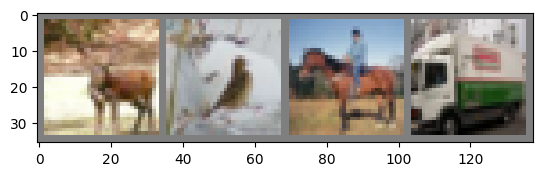

deer  bird  horse truck


In [ ]:
# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize: xxx / std + mean
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [53]:
images.shape, labels.shape

(torch.Size([4, 3, 32, 32]), torch.Size([4]))

### Define a Convolutional Neural Network

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [54]:
# net
# dispay: (1) torchview with graphviz, (2) `SummaryWriter` with TensorBoard, (3) torchinfo
from torchinfo import summary
summary(net, input_size=(4, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [4, 10]                   --
├─Conv2d: 1-1                            [4, 6, 28, 28]            456
├─MaxPool2d: 1-2                         [4, 6, 14, 14]            --
├─Conv2d: 1-3                            [4, 16, 10, 10]           2,416
├─MaxPool2d: 1-4                         [4, 16, 5, 5]             --
├─Linear: 1-5                            [4, 120]                  48,120
├─Linear: 1-6                            [4, 84]                   10,164
├─Linear: 1-7                            [4, 10]                   850
Total params: 62,006
Trainable params: 62,006
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.63
Input size (MB): 0.05
Forward/backward pass size (MB): 0.21
Params size (MB): 0.25
Estimated Total Size (MB): 0.51

### Define a Loss function and optimizer

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

### Train the network

In [35]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.304
[1,  4000] loss: 2.305
[1,  6000] loss: 2.305
[1,  8000] loss: 2.305
[1, 10000] loss: 2.305
[1, 12000] loss: 2.305
[2,  2000] loss: 2.305
[2,  4000] loss: 2.305
[2,  6000] loss: 2.304
[2,  8000] loss: 2.305
[2, 10000] loss: 2.305
[2, 12000] loss: 2.305
Finished Training


### Save models

In [ ]:
PATH = './model/cifar_net.pt'
torch.save(net.state_dict(), PATH)

### Test the network on the test data

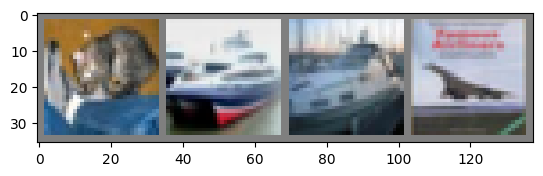

GroundTruth:  cat   ship  ship  plane
Predicted:  cat   ship  plane car  


In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

# load saved model
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

outputs = net(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

In [28]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')


# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy of the network on the 10000 test images: 53 %
Accuracy for class: plane is 68.5 %
Accuracy for class: car   is 55.8 %
Accuracy for class: bird  is 19.4 %
Accuracy for class: cat   is 25.3 %
Accuracy for class: deer  is 56.4 %
Accuracy for class: dog   is 49.9 %
Accuracy for class: frog  is 61.5 %
Accuracy for class: horse is 75.1 %
Accuracy for class: ship  is 62.7 %
Accuracy for class: truck is 61.5 %


### Training on GPU

In [29]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')
device

device(type='cpu')

In [33]:
# convert their parameters and buffers to CPU/CUDA tensors
net.to(device=device)

# send the inputs and targets at every step to the GPU too
# data[0].to(device=device)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

# Models

## Built-in Models

In [73]:
from torchvision import models

import inspect

rows = []
def get_modules(m, level=0):
  if level > 0:
    return
  for mm in inspect.getmembers(m, lambda _m: 
                              #  inspect.isclass(_m) or 
                               inspect.isfunction(_m)):
    # print("-" * level, mm[0], (mm[1].__doc__ or '').replace("\n", " ")[:200])
    rows.append((mm[1].__name__, (mm[1].__doc__ or '').replace("\n", " ")[:200]))
    get_modules(mm[1], level+1)

get_modules(models)

pd.set_option('display.max_rows', None)
df = pd.DataFrame(rows, columns=["module", "description"])
df.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]}
]).set_properties(**{'text-align': 'left'})

,module,description
0,alexnet,AlexNet model architecture from `One weird trick for parallelizing convolutional neural networks `__. .. note:: AlexNet was originally introduced in the `
1,convnext_base,ConvNeXt Base model architecture from the `A ConvNet for the 2020s `_ paper. Args: weights (:class:`~torchvision.models.convnext.ConvNeXt_Base_Weight
2,convnext_large,ConvNeXt Large model architecture from the `A ConvNet for the 2020s `_ paper. Args: weights (:class:`~torchvision.models.convnext.ConvNeXt_Large_Weig
3,convnext_small,ConvNeXt Small model architecture from the `A ConvNet for the 2020s `_ paper. Args: weights (:class:`~torchvision.models.convnext.ConvNeXt_Small_Weig
4,convnext_tiny,ConvNeXt Tiny model architecture from the `A ConvNet for the 2020s `_ paper. Args: weights (:class:`~torchvision.models.convnext.ConvNeXt_Tiny_Weight
5,densenet121,"Densenet-121 model from `Densely Connected Convolutional Networks `_. Args: weights (:class:`~torchvision.models.DenseNet121_Weights`, optional): The"
6,densenet161,"Densenet-161 model from `Densely Connected Convolutional Networks `_. Args: weights (:class:`~torchvision.models.DenseNet161_Weights`, optional): The"
7,densenet169,"Densenet-169 model from `Densely Connected Convolutional Networks `_. Args: weights (:class:`~torchvision.models.DenseNet169_Weights`, optional): The"
8,densenet201,"Densenet-201 model from `Densely Connected Convolutional Networks `_. Args: weights (:class:`~torchvision.models.DenseNet201_Weights`, optional): The"
9,efficientnet_b0,EfficientNet B0 model architecture from the `EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks `_ paper. Args: weights (:class


In [74]:
alexnet = models.alexnet(num_classes=2)
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

## PyTorch Hub

### List models

In [72]:
torch.hub.list("pytorch/vision", force_reload=True)

Downloading: "https://github.com/pytorch/vision/zipball/main" to C:\Users\zhouj/.cache\torch\hub\main.zip


['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fcn_resnet101',
 'fcn_resnet50',
 'get_model_weights',
 'get_weight',
 'googlenet',
 'inception_v3',
 'lraspp_mobilenet_v3_large',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'r2plus1d_18',
 'r3d_18',
 'raft_large',
 'raft_small',
 'regnet_x_16gf',
 'regnet_x_1_6gf',
 'regnet_x_32gf',
 'regnet_x_3_2gf',
 'regnet_x_400mf',
 'regnet_x_800mf',
 'regnet_x_8gf',
 'regnet_y_128gf',
 'regnet_y_16gf',
 'regnet_y_1

### Download models

In [4]:
torch.hub.set_dir("D:/software/pytorch/.cache")
print(torch.hub.get_dir())

%env TORCH_HOME=D:/software/pytorch/.cache

D:/software/pytorch/.cache
env: TORCH_HOME=D:/software/pytorch/.cache


In [ ]:
import torchvision.models as models

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to D:/software/pytorch/.cache\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [02:57<00:00, 576kB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

## torch.nn

In [4]:
from torch import nn
import inspect

rows = []
def get_modules(m, level=0):
  if level > 0:
    return
  for mm in inspect.getmembers(m, lambda _m: 
                               inspect.isclass(_m) or 
                               inspect.isfunction(_m)):
    # print("-" * level, mm[0], (mm[1].__doc__ or '').replace("\n", " ")[:200])
    rows.append((mm[1].__name__, (mm[1].__doc__ or '').replace("\n", " ")[:200]))
    get_modules(mm[1], level+1)

get_modules(nn)

pd.set_option('display.max_rows', None)
df = pd.DataFrame(rows, columns=["module", "description"])
df.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]}
]).set_properties(**{'text-align': 'left'})

,module,description
0,AdaptiveAvgPool1d,"Applies a 1D adaptive average pooling over an input signal composed of several input planes. The output size is :math:`L_{out}`, for any input size. The number of output features is equal to"
1,AdaptiveAvgPool2d,"Applies a 2D adaptive average pooling over an input signal composed of several input planes. The output is of size H x W, for any input size. The number of output features is equal to the num"
2,AdaptiveAvgPool3d,"Applies a 3D adaptive average pooling over an input signal composed of several input planes. The output is of size D x H x W, for any input size. The number of output features is equal to the"
3,AdaptiveLogSoftmaxWithLoss,"Efficient softmax approximation. As described in `Efficient softmax approximation for GPUs by Edouard Grave, Armand Joulin, Moustapha Cissé, David Grangier, and Hervé Jégou <https://a"
4,AdaptiveMaxPool1d,"Applies a 1D adaptive max pooling over an input signal composed of several input planes. The output size is :math:`L_{out}`, for any input size. The number of output features is equal to the"
5,AdaptiveMaxPool2d,"Applies a 2D adaptive max pooling over an input signal composed of several input planes. The output is of size :math:`H_{out} \times W_{out}`, for any input size. The number of output feature"
6,AdaptiveMaxPool3d,"Applies a 3D adaptive max pooling over an input signal composed of several input planes. The output is of size :math:`D_{out} \times H_{out} \times W_{out}`, for any input size. The number of"
7,AlphaDropout,"Applies Alpha Dropout over the input. Alpha Dropout is a type of Dropout that maintains the self-normalizing property. For an input with zero mean and unit standard deviation, the output"
8,AvgPool1d,"Applies a 1D average pooling over an input signal composed of several input planes. In the simplest case, the output value of the layer with input size :math:`(N, C, L)`, output :math:`(N, C,"
9,AvgPool2d,"Applies a 2D average pooling over an input signal composed of several input planes. In the simplest case, the output value of the layer with input size :math:`(N, C, H, W)`, output :math:`(N,"


# Datasets

## Kagglehub

In [75]:
import kagglehub
import os

os.environ['KAGGLEHUB_CACHE'] = "./data"

In [19]:
# https://www.kaggle.com/datasets/zuraiz/fish-vs-cats-imagenet-subdataset
path = kagglehub.dataset_download("zuraiz/fish-vs-cats-imagenet-subdataset")
print("Path to dataset files:", path)

100%|██████████| 67.7M/67.7M [01:27<00:00, 810kB/s]

Extracting files...


Path to dataset files: ./data\datasets\zuraiz\fish-vs-cats-imagenet-subdataset\versions\2


In [76]:
# https://www.kaggle.com/datasets/kazanova/sentiment140
path = kagglehub.dataset_download("kazanova/sentiment140")
print("Path to dataset files:", path)

100%|██████████| 80.9M/80.9M [01:32<00:00, 916kB/s]

Extracting files...


Path to dataset files: ./data\datasets\kazanova\sentiment140\versions\2


In [ ]:
# https://github.com/karolpiczak/ESC-50

# https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50
# path = kagglehub.dataset_download("mmoreaux/environmental-sound-classification-50")
# print("Path to dataset files:", path)

In [78]:
from IPython import display

display.Audio('./data/ESC-50/audio/1-100032-A-0.wav')

## Built-in Datasets

In [81]:
from torchvision import datasets

import inspect

rows = []


def get_modules(m, level=0):
  if level > 0:
    return
  for mm in inspect.getmembers(m, lambda _m:
                               inspect.isclass(_m)):
    # print("-" * level, mm[0], (mm[1].__doc__ or '').replace("\n", " ")[:200])
    rows.append(
        (mm[1].__name__, (mm[1].__doc__ or '').replace("\n", " ")[:200]))
    get_modules(mm[1], level+1)


get_modules(datasets)

pd.set_option('display.max_rows', None)
df = pd.DataFrame(rows, columns=["module", "description"])
df.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]}
]).set_properties(**{'text-align': 'left'})

,module,description
0,CIFAR10,`CIFAR10 `_ Dataset. Args: root (str or ``pathlib.Path``): Root directory of dataset where directory ``cifar-10-batches-py`` exist
1,CIFAR100,`CIFAR100 `_ Dataset. This is a subclass of the `CIFAR10` Dataset.
2,CLEVRClassification,`CLEVR `_ classification dataset. The number of objects in a scene are used as label. Args: root (str or ``pathlib.Path``): Root direc
3,CREStereo,Synthetic dataset used in training the `CREStereo `_ architecture. Dataset details on the official paper `repo `
4,Caltech101,`Caltech 101 `_ Dataset. .. warning:: This class needs `scipy `_ to load target files from `.mat` format. Args:
5,Caltech256,`Caltech 256 `_ Dataset. Args: root (str or ``pathlib.Path``): Root directory of dataset where directory ``caltech256`` exists or will
6,CarlaStereo,Carla simulator data linked in the `CREStereo github repo `_. The dataset is expected to have the following structure: :: root
7,CelebA,`Large-scale CelebFaces Attributes (CelebA) Dataset `_ Dataset. Args: root (str or ``pathlib.Path``): Root directory where images are dow
8,Cityscapes,`Cityscapes `_ Dataset. Args: root (str or ``pathlib.Path``): Root directory of dataset where directory ``leftImg8bit`` and ``gtFine`` or `
9,CocoCaptions,"`MS Coco Captions `_ Dataset. It requires `pycocotools `_ to be installed, which could be installed via ``pip inst"


## Inspect datasets

In [5]:
import torchvision

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True)

100%|██████████| 9.91M/9.91M [00:13<00:00, 745kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 118kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 638kB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


In [ ]:
trainset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train

In [7]:
type(trainset).__mro__

(torchvision.datasets.mnist.MNIST,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

In [12]:
img, label = trainset[10]

print(label)
img

3


In [13]:
img.size

(28, 28)

## Transform datasets

In [24]:
from torchvision import transforms
from torchvision.transforms import v2
import inspect


def get_modules_to_pd(module):
  rows = []
  def get_modules(m, level=0):
    if level > 0:
      return
    for mm in inspect.getmembers(m, lambda _m: 
                                inspect.isclass(_m) or 
                                inspect.isfunction(_m)):
      # print("-" * level, mm[0], (mm[1].__doc__ or '').replace("\n", " ")[:200])
      rows.append((mm[1].__name__, (mm[1].__doc__ or '').replace("\n", " ")[:200]))
      get_modules(mm[1], level+1)

  get_modules(module)

  pd.set_option('display.max_rows', None)
  df = pd.DataFrame(rows, columns=["module", "description"])
  df.style.set_table_styles([
      {'selector': 'th', 'props': [('text-align', 'left')]}
  ]).set_properties(**{'text-align': 'left'})
  return df

In [25]:
get_modules_to_pd(module=transforms)

,module,description
0,AugMix,AugMix data augmentation method based on `...
1,AutoAugment,AutoAugment data augmentation method based on ...
2,AutoAugmentPolicy,AutoAugment policies learned on different data...
3,CenterCrop,Crops the given image at the center. If th...
4,ColorJitter,"Randomly change the brightness, contrast, satu..."
5,Compose,Composes several transforms together. This tra...
6,ConvertImageDtype,Convert a tensor image to the given ``dtype`` ...
7,ElasticTransform,Transform a tensor image with elastic transfor...
8,FiveCrop,Crop the given image into four corners and the...
9,GaussianBlur,Blurs image with randomly chosen Gaussian blur...


In [26]:
get_modules_to_pd(module=v2)

,module,description
0,AugMix,AugMix data augmentation method based on `...
1,AutoAugment,AutoAugment data augmentation method based on ...
2,AutoAugmentPolicy,AutoAugment policies learned on different data...
3,CenterCrop,Crop the input at the center. If the inpu...
4,ClampBoundingBoxes,Clamp bounding boxes to their corresponding im...
5,ClampKeyPoints,Clamp keypoints to their corresponding image d...
6,ColorJitter,"Randomly change the brightness, contrast, satu..."
7,Compose,Composes several transforms together. Thi...
8,ConvertBoundingBoxFormat,Convert bounding box coordinates to the given ...
9,ConvertImageDtype,"[DEPRECATED] Use ``v2.ToDtype(dtype, scale=Tru..."


In [34]:
img_t = transforms.ToTensor()(img)
img_t.shape, img_t.dtype

(torch.Size([1, 28, 28]), torch.float32)

In [ ]:
transforms.ToPILImage()(img_t.permute(0, 2, 1))

# torch.optim: Optimization

In [3]:
from torch import optim
import inspect

rows = []
def get_modules(m, level=0):
  if level > 0:
    return
  for mm in inspect.getmembers(m, lambda _m: 
                               inspect.isclass(_m) or 
                               inspect.isfunction(_m)):
    # print("-" * level, mm[0], (mm[1].__doc__ or '').replace("\n", " ")[:200])
    rows.append((mm[1].__name__, (mm[1].__doc__ or '').replace("\n", " ")[:200]))
    get_modules(mm[1], level+1)

get_modules(optim)

pd.set_option('display.max_rows', None)
df = pd.DataFrame(rows, columns=["module", "description"])
df.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]}
]).set_properties(**{'text-align': 'left'})

,module,description
0,ASGD,Implements Averaged Stochastic Gradient Descent. It has been proposed in `Acceleration of stochastic approximation by averaging`_. Args: params (iterable): iterable of parameters
1,Adadelta,Implements Adadelta algorithm. .. math:: \begin{aligned} &\rule{110mm}{0.4pt} \\ &\textbf{input}
2,Adafactor,Implements Adafactor algorithm. .. math:: \begin{aligned} &\rule{110mm}{0.4pt} \\ &\textbf{input}
3,Adagrad,Implements Adagrad algorithm. .. math:: \begin{aligned} &\rule{110mm}{0.4pt} \\ &\textbf{input}
4,Adam,Implements Adam algorithm. .. math:: \begin{aligned} &\rule{110mm}{0.4pt} \\ &\textbf{input} :
5,AdamW,"Implements AdamW algorithm, where weight decay does not accumulate in the momentum nor variance. .. math:: \begin{aligned} &\rule{110mm}{0.4pt}"
6,Adamax,Implements Adamax algorithm (a variant of Adam based on infinity norm). .. math:: \begin{aligned} &\rule{110mm}{0.4pt}
7,LBFGS,Implements L-BFGS algorithm. Heavily inspired by `minFunc `_. .. warning:: This optimizer doesn't support per-parameter opt
8,Muon,"Implements Muon algorithm. .. math:: \begin{aligned} &\rule{110mm}{0.4pt} \\ &\textbf{input} : \gamma \text{ (lr)},\ \lambda \text{ (weight decay)},\"
9,NAdam,Implements NAdam algorithm. .. math:: \begin{aligned} &\rule{110mm}{0.4pt} \\ &\textbf{input} :


# Integration: Hugging Face

In [1]:
%load_ext dotenv
%dotenv .env/hf.env

In [2]:
!hf cache ls

ID                           SIZE LAST_ACCESSED LAST_MODIFIED  REFS
--------------------------- ----- ------------- -------------- ----
model/google/gemma-4-E4B-it 16.0G 1 minute ago  25 minutes ago main

Found 1 repo(s) for a total of 2 revision(s) and 16.0G on disk.


In [ ]:
%run pytorch_hf_gemma_text.py

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

量子计算是一种利用量子力学原理（如叠加态和量子纠缠）来处理信息，从而能解决传统计算机无法高效解决的复杂计算问题的计算范式。


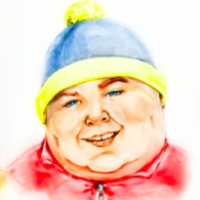

: 

In [ ]:
from IPython.display import display, Image
display(Image("data/images/avatar.png"))

In [1]:
%run pytorch_hf_gemma_image.py

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

{'role': 'assistant', 'content': 'This image is a **watercolor portrait** of a man.\n\nHere are some key details about what is shown:\n\n*   **Subject:** A middle-aged or older man with a round, jovial face and a smiling expression.\n*   **Attire:** He is wearing a bright **yellow cap** underneath a **blue winter hat** (which has a yellow pom-pom on top). He also appears to be wearing a **red or bright pink coat/jacket**.\n*   **Style:** The style is painterly, characteristic of watercolor, giving the image a soft and somewhat cheerful appearance.\n*   **Overall Vibe:** The portrait conveys a friendly, hearty, and perhaps outdoorsy or jolly personality.'}


# Cleanup

In [ ]:
# List all installed pip packages with summaries.
# https://www.kaggle.com/code/twoturtles/kaggle-installed-packages

import requests
import json
import subprocess
import pandas as pd
from tqdm import tqdm

# Get package description from PyPI.
def get_package_description(package_name):
    try:
        response = requests.get(f"https://pypi.org/pypi/{package_name}/json")
        if response.status_code == 200:
            data = response.json()
            return data["info"]["summary"]
        else:
            return "Description not found"
    except:
        return "Failed to fetch description"

# Use pip list to get list of packages.
installed_packages = subprocess.run(['uv', 'pip', 'list', '--format', 'json'], capture_output=True, text=True)
packages = json.loads(installed_packages.stdout)

# Print package names with descriptions.
rows = []
with tqdm(total=len(packages)) as pbar:
    for i, package in enumerate(packages):
        description = get_package_description(package['name'])
        rows.append((package['name'], package['version'], description))
        pbar.update(1)

pd.set_option('display.max_rows', None)
df = pd.DataFrame(rows, columns=["package", "version", "description"])
df.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]}
]).set_properties(**{'text-align': 'left'})

100%|██████████| 117/117 [00:41<00:00,  2.81it/s]


,#,package,version,description
0,1,anyio,4.13.0,High-level concurrency and networking framework on top of asyncio or Trio
1,2,argon2-cffi,25.1.0,Argon2 for Python
2,3,argon2-cffi-bindings,25.1.0,Low-level CFFI bindings for Argon2
3,4,arrow,1.4.0,Better dates & times for Python
4,5,asttokens,3.0.1,Annotate AST trees with source code positions
5,6,async-lru,2.3.0,Simple LRU cache for asyncio
6,7,attrs,26.1.0,Classes Without Boilerplate
7,8,babel,2.18.0,Internationalization utilities
8,9,beautifulsoup4,4.14.3,Screen-scraping library
9,10,bleach,6.3.0,An easy safelist-based HTML-sanitizing tool.
